#Practical Exercise: GAN on Lego Brick Images

1. Understanding the Dataset

In [ ]:
pip install kaggle

In [ ]:
os.environ['KAGGLE_USERNAME'] = "Tiney"
os.environ['KAGGLE_KEY'] = "KGAT_48a2c68e0e8563906358ca91d83844b7"

# On vérifie que ça pointe bien au bon endroit (optionnel mais recommandé)
!mkdir -p ~/.kaggle
!echo '{"username":"'$KAGGLE_USERNAME'","key":"'$KAGGLE_KEY'"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d joosthazelzet/lego-brick-images --unzip

Dataset URL: https://www.kaggle.com/datasets/joosthazelzet/lego-brick-images
License(s): GPL-2.0
100% 1.00G/1.00G [00:10<00:00, 102MB/s] 



In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.utils as vutils

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import transforms

from pathlib import Path

from PIL import Image

import random

In [ ]:
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# --------------------
#   Hyperparameters
# --------------------
IMAGE_SIZE = 64       # Input/Output resolution
CHANNELS = 1          # Grayscale = 1, for color use 3
BATCH_SIZE = 128
Z_DIM = 100           # Dim of latent vector
EPOCHS = 50  #On va réduire le nb epochs de 100--> 50, en raison d'un pc peu performant
LEARNING_RATE = 0.0002
BETA1 = 0.5
BETA2 = 0.999
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # Dynamically set device based on CUDA availability
NOISE_PARAM = 0.1     # Label smoothing/noise
# --------------------
#   Transforms
# --------------------
# Define the transforms: Grayscale + Resize + Normalize
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),   # Grayscale
    transforms.Resize((64, 64)),   # Resiz
    transforms.ToTensor(),
    transforms.Normalize((0.1,), (0.1,)) # Center around 0 with range [0,1][0,1]
])

3. Build Dataset & DataLoader
Simple custom dataset that returns images (no labels) from a specified folder

In [ ]:
# --------------------
# Dataset & DataLoader
#--------------------

class ImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Gather all image files with .png, .jpg, .jpeg
        self.image_files = sorted([
            f for f in os.listdir(root_dir)
                        if f.endswith(('.png', '.jpg', '.jpeg'))
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")  # or "L" for grayscale
        if self.transform:
            image = self.transform(image)
        return image


In [ ]:
# Specify your dataset folder path
dataset_path = "dataset"
dataset = ImageDataset(dataset_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


4. Plot few example

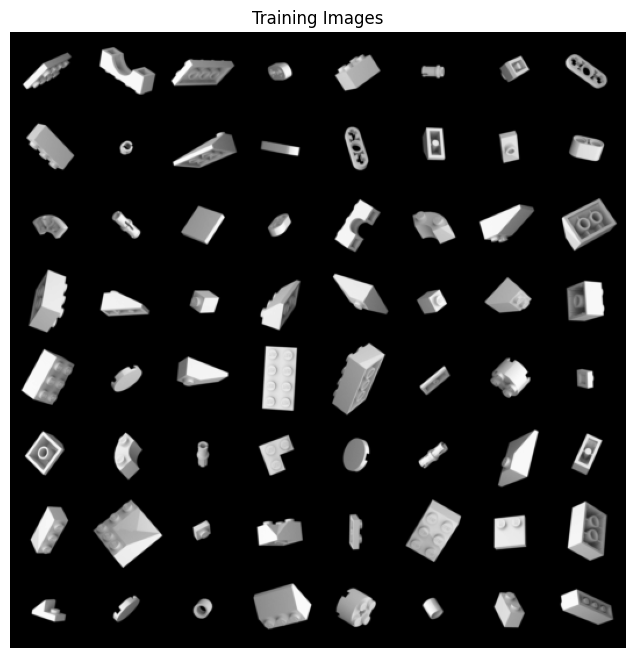

In [ ]:
def plot_sample_images(loader):
    real_batch = next(iter(loader))

    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title("Training Images")
    grid_img = vutils.make_grid(real_batch[:64], padding=2, normalize=True)

    # Convert to numpy array for matplotlib and remove the channel dimension for grayscale
    np_grid_img = grid_img.numpy().transpose(1, 2, 0).squeeze()

    plt.imshow(np_grid_img, cmap='gray') # Use cmap='gray' for grayscale images
    plt.show()
plot_sample_images(dataloader)

### 2. Building the GAN Architecture

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # Input shape: (CHANNELS, 64, 64)
            nn.Conv2d(CHANNELS, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            # Output shape: (1, 1, 1)
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
            nn.Flatten(start_dim=1)
        )

    def forward(self, x):
        return self.model(x)

### 2.2 Generator
* Input: A random noise vector z of dimension ZdimZdim​ (e.g., 100).
* Goal: Generate a 64×64 grayscale image from random noise.
* Layers: Use ConvTranspose2d (also called deconvolution) to upsample the noise from 1×1 to 64×64.
* Activation:
Typically LeakyReLU after each layer (except the last).
Final layer often uses Tanh (so outputs are in [−1,1][−1,1] range).

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            # Input: (Z_DIM, 1, 1)
            nn.ConvTranspose2d(Z_DIM, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(64, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# Re-instantiate models to apply fixes
critic = Discriminator().to(DEVICE)
generator = Generator().to(DEVICE)

In [ ]:
generator = Generator().to(DEVICE)

### 3. Training Setup
* Loss Functions:
* Use Binary Cross-Entropy (BCE) Loss for both generator and discriminator.
    Real images → label = 1
    
    Fake images → label = 0
* Optimizers:

    Typically Adam with betas=(0.5, 0.999).
* Noise Labels (Optional trick):

    Sometimes add label noise: slightly randomizing real/fake labels or values near 1/0.

    This can help prevent the discriminator from overpowering the generator.



In [ ]:
#------------------------
#  Losses & Optimizers
#------------------------
criterion = nn.BCELoss()
d_optimizer = optim.Adam(critic.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
g_optimizer = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

#------------------------
# Training
#------------------------

g_loss_values = []
d_loss_values = []
g_acc_values = []
d_acc_values = []

for epoch in range(EPOCHS):
    g_loss_batch = []
    d_loss_batch = []
    g_acc_batch = []
    d_acc_batch = []

    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch+1}/{EPOCHS}")
    for i, real_images in progress_bar:
        real_images = real_images.to(DEVICE)
        batch_size = real_images.size(0)

        # 1) Train Discriminator
        critic.zero_grad()

        # Labels
        real_labels = torch.full((batch_size, 1), 1.0, device=DEVICE)
        real_noisy_labels = real_labels - NOISE_PARAM * torch.rand_like(real_labels)
        fake_labels = torch.full((batch_size, 1), 0.0, device=DEVICE)
        fake_noisy_labels = fake_labels + NOISE_PARAM * torch.rand_like(fake_labels)

        # Real images
        real_preds = critic(real_images)
        real_loss = criterion(real_preds, real_noisy_labels)

        # Fake images
        z = torch.randn(batch_size, Z_DIM, 1, 1, device=DEVICE)
        fake_images = generator(z)
        fake_preds = critic(fake_images.detach())
        fake_loss = criterion(fake_preds, fake_noisy_labels)

        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        d_optimizer.step()

        # Accuracy
        d_real_acc = (real_preds.round() == real_labels).float().mean().item()
        d_fake_acc = (fake_preds.round() == fake_labels).float().mean().item()
        d_acc = (d_real_acc + d_fake_acc) / 2

        # 2) Train Generator
        generator.zero_grad()
        fake_preds = critic(fake_images)
        g_loss = criterion(fake_preds, real_labels) # Generator wants fake to be seen as real
        g_loss.backward()
        g_optimizer.step()

        g_acc = (fake_preds.round() == real_labels).float().mean().item()

        d_loss_batch.append(d_loss.item())
        g_loss_batch.append(g_loss.item())
        d_acc_batch.append(d_acc)
        g_acc_batch.append(g_acc)

        progress_bar.set_postfix(D_Loss=d_loss.item(), G_Loss=g_loss.item())

    d_loss_values.append(np.mean(d_loss_batch))
    g_loss_values.append(np.mean(g_loss_batch))
    d_acc_values.append(np.mean(d_acc_batch))
    g_acc_values.append(np.mean(g_acc_batch))

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            z_sample = torch.randn(16, Z_DIM, 1, 1, device=DEVICE)
            fake_sample = generator(z_sample).cpu()
        vutils.save_image(fake_sample, f"fake_sample_epoch_{epoch+1:03d}.png", normalize=True)

Epoch 50/50: 100%|██████████| 313/313 [02:40<00:00,  1.95it/s, D_Loss=0.381, G_Loss=3.75]


If dose work then you can use a pre-trained model:

In [ ]:
# Load state dictionaries
generator.load_state_dict(torch.load(GEN_PATH, map_location=DEVICE))
critic.load_state_dict(torch.load(CRITIC_PATH, map_location=DEVICE))
generator.eval()
critic.eval()


NameError: name 'generator' is not defined

### 5. Monitoring Progress

In [ ]:
#--------------------------
#  Plotting Results
#--------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

titles = ['epoch_g_loss', 'epoch_g_acc', 'epoch_d_loss', 'epoch_d_acc']
data = [g_loss_values, g_acc_values, d_loss_values, d_acc_values]

for ax, title, values in zip(axes, titles, data):
    ax.plot(values, color='brown')
    ax.set_title(title)
    ax.grid(True)

plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

### 6. Generating and Evaluating

In [ ]:
#--------------------------
#  Sampling
#--------------------------
# Generate a grid of images from random noise
grid_width, grid_height = (8, 4)
z_sample = torch.xxx(xxx * xxx, xxx, 1, 1, device=DEVICE)
gen_imgs = xxx(z_sample).cpu().detach()

# Show them in a matplotlib grid
fig = plt.figure(figsize=(grid_width, grid_height))
for i in range(grid_width * grid_height):
    ax = fig.add_subplot(grid_height, grid_width, i + 1)
    ax.axis("off")
    # Each image shape: (1, 64, 64)
    ax.imshow(gen_imgs[i, 0, :, :], cmap="gray")
plt.show()

